<a href="https://colab.research.google.com/github/Agneta-mkng/Ai-assignment/blob/main/ai_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [80]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [81]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [82]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [83]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9263 - loss: 0.2597
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9665 - loss: 0.1118
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9769 - loss: 0.0771
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9824 - loss: 0.0574
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0440


In [85]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9779 - loss: 0.0745


[0.07447108626365662, 0.9779000282287598]

In [86]:
import base64
from PIL import Image
from io import BytesIO
import numpy as np

def predict_digit(data):
    # decode image
    image_bytes = base64.b64decode(data.split(',')[1])
    image = Image.open(BytesIO(image_bytes)).convert('L')

    # resize to MNIST format
    image = image.resize((28, 28))

    img_array = np.array(image)

    # show what model sees
    plt.imshow(img_array, cmap='gray')
    plt.title("Input to model")
    plt.show()

    # normalize + fix polarity
    img_array = img_array / 255.0

    # reshape for model
    img_array = img_array.reshape(1, 28, 28)

    # predict
    prediction = model.predict(img_array)
    print("Predicted digit:", np.argmax(prediction))

from google.colab import output
output.register_callback('notebook.predict', predict_digit)


In [87]:
print("mean pixel value:", np.mean(img_array))

mean pixel value: 0.9960937497644194


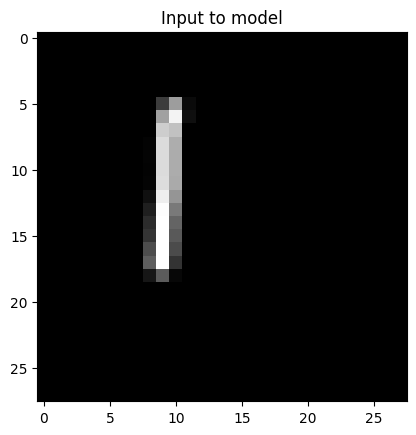

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted digit: 4


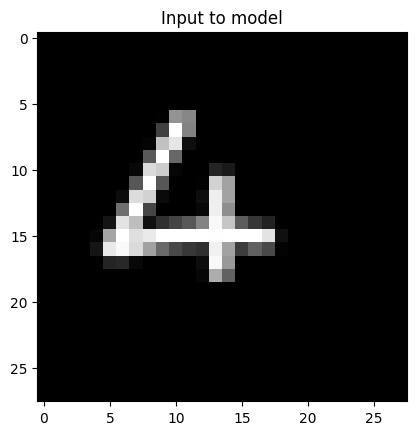

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted digit: 4


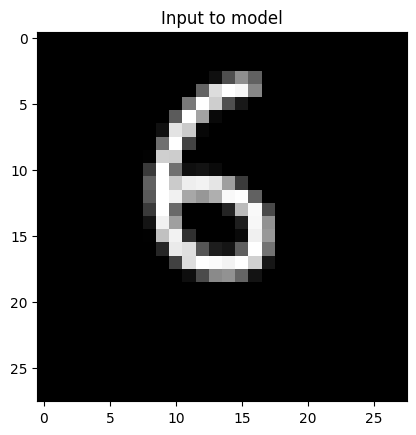

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted digit: 4


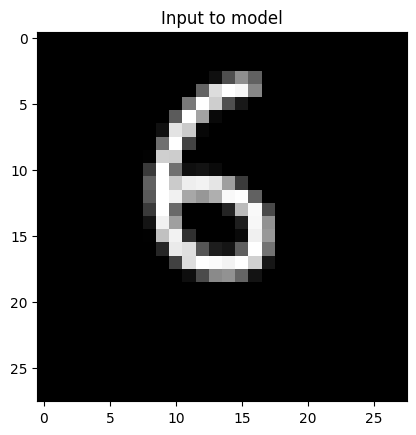

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted digit: 4


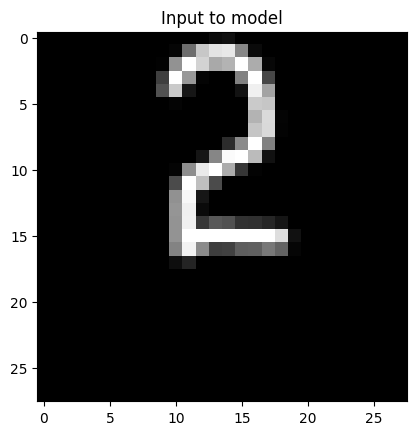

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted digit: 2


In [88]:
from IPython.display import HTML

canvas_html = """
<canvas id="canvas" width="280" height="280" style="border:1px solid black;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="predict()">Predict</button>

<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 15;
ctx.lineCap = 'round';

var drawing = false;

canvas.onmousedown = e => { drawing = true; }
canvas.onmouseup = e => { drawing = false; ctx.beginPath(); }
canvas.onmousemove = e => {
  if (!drawing) return;
  ctx.lineTo(e.offsetX, e.offsetY);
  ctx.stroke();
  ctx.beginPath();
  ctx.moveTo(e.offsetX, e.offsetY);
}

function clearCanvas() {
  ctx.fillStyle = "black";
  ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function predict() {
  var dataURL = canvas.toDataURL();
  google.colab.kernel.invokeFunction('notebook.predict', [dataURL], {});
}
</script>
"""

display(HTML(canvas_html))